In [1]:
import quanguru as qg
import numpy as np
import matplotlib.pyplot as plt
import platform

# 20 - Simultaneous Simulation JC and Rabi models

The Rabi Hamiltonian (also called the quantum Rabi model) is written as:

$H_{JC} = \hbar\omega_{c} a^{\dagger}a + \frac{1}{2}\hbar\omega_{q}\sigma_{z} + \hbar g(a^{\dagger}+ a)(\sigma_{+} + \sigma_{-})$
<br> <br>

Previously, we have looked at the Jaynes-Cummings model descibed by:
$H_{JC} = \hbar\omega_{c} a^{\dagger}a + \frac{1}{2}\hbar\omega_{q}\sigma_{z} + \hbar g(a^{\dagger}\sigma_{-} + a\sigma_{+})$

The JC model is derived from the Rabi model by applying the Rotating Wave Approximation (RWA), which drops the counter-rotating (anti-resonant) terms 
$ a^{\dagger} \sigma_{+}$ and $a \sigma_{-}$  under the assumption that $g ≪ \omega_{c}, \omega_{q}$.

In this tutorial we will demonstrate how to simultaneously simulate both quantum systems to compare the two models.
​

In [2]:
# parameters for the Hamiltonian
qubitFreq = 1
cavityFreq = 1
couplingFreq = 0.25
cavityDim = 5

# parameters for the evolution
totalTime = 3*(np.pi/couplingFreq)
timeStep = 0.1

In [3]:
# Qubit for the JC model
QubitJC = qg.Qubit(frequency=qubitFreq)

# Cavity for the JC model
CavityJC = qg.Cavity(dimension=cavityDim, frequency=cavityFreq)

# JC model consists of a qubit and cavity
# and this is the 'free evolution' part of the JC-Hamiltonian
JCSystem = QubitJC + CavityJC

Rather than redefining a new qubit and cavity for the Rabi model, we use the `copy()` method to duplicate the `JCSystem` structure. This preserves all system parameters (`frequency`, `dimension`) and creates independent copies (modifications to one don't affect the other).



In [4]:
RabiSystem = JCSystem.copy()

`QuanGuru` provides convenient methods for common interaction Hamiltonians:
- `JC(g)`: Adds Jaynes-Cummings coupling $g(a^{\dagger}\sigma_{-} + a\sigma_{+})$
- `Rabi(g)`: Adds quantum Rabi coupling $g(a^{\dagger} + a)(\sigma_{+} + \sigma_{-})$

These methods automatically handle operator ordering and composite system structure.

An example of how to construct these manually is on the next tutorial.

In [5]:
# create the JC coupling using built-in coupling extension
JCSystem.JC(couplingFreq)

RabiCoupling = RabiSystem.Rabi(couplingFreq)

The `Simulation` object manages multiple systems:
- `subSys=[JCSystem, RabiSystem]`: Both systems evolve in parallel
- `initialStateSystem=JCSystem`: Specifies which system's Hilbert space the initial state refers to

The initial state is automatically mapped to both systems.

The sweep uses `system=[CavityJC, "Cavity2"]` to simultaneously vary the cavity frequency in both models. The string `"Cavity2"` refers to the cavity in the copied Rabi system (automatically named during copy).


In [6]:
# simulation contains the systems, protocol, and sweeps
simulation = qg.Simulation(subSys=[JCSystem, RabiSystem])

# simulation stores the evolution parameters
simulation.stepSize = timeStep
simulation.totalTime = totalTime

# initial state of the simulation
simulation.initialStateSystem = JCSystem
simulation.initialState = [1, 1]

# need to include both systems in the frequency sweep
freqSweep = simulation.Sweep.createSweep(
                    system=[CavityJC, "Cavity2"],
                    sweepKey="frequency",
                    sweepMax=qubitFreq+cavityFreq,
                    sweepMin=qubitFreq-cavityFreq,
                    sweepStep=.025)

We can create a composite operator in the extended Hilbert space so that measurement can be made without needing to project the state in the compute function.

Here, we create the composite qubit Pauli-Z operator $\langle \sigma_{z} \rangle$ acting on the full qubit $\otimes$ cavity space. 
This gives +1 for $\vert e \rangle$ and -1 for $\vert g \rangle$. We compute this for each model.

We also compute the fidelity between the states from the JC and Rabi models using `qg.fidelityPure`.

The `singleResult` property stores individual results at each time step, automatically organizing them by sweep parameters.




In [7]:

# create sigma Z operator in the extended Hilbert space
compositeSZ = qg.compositeOp(qg.sigmaz(),   dimA=cavityDim)

# calculate the desired results and store
def compute(sim, args):
    stateJC = args[0]
    stateRabi = args[1]

    res = sim.qRes
    res.singleResult = ['zRabi', qg.expectation(compositeSZ, stateRabi)]
    res.singleResult = ['zJC', qg.expectation(compositeSZ, stateJC)]

    # fidelityPure computes and returns fidelity between two states
    res.singleResult = ['fidelityJC', qg.fidelityPure(stateRabi, stateJC)]

simulation.compute = compute

<span style="color:red" font-weight="bold"> IMPORTANT NOTE FOR WINDOWS USERS : MULTI-PROCESSING (p=True) DOES NOT WORK WITH NOTEBOOK

You can use a python script, but you will need to make sure that the critical parts of the code are under ``` if __name__ == "__main__": ```

In [8]:
# do not store the states
simulation.delStates = True

# run the simulation
# p=True uses multi-processing for the sweep
simulation.run(p=(platform.system() != 'Windows'))

Starting sequential sweep with 81 parameter combinations...
Simulation Start:	2025-11-30 18:01:32
[████████████████████████████████████████] 100.0% | Est. Finish: 2025-11-30 18:01:43
Simulation completed in 00h 00m 10s

[]

The JC model plot shows:
- **On-resonance**: Complete Rabi oscillations with period $\sim \pi/g$
- **Off-resonance**: Reduced oscillation amplitude with increased frequency
- **Chevron pattern**: Characteristic JC detuning dependence
- **Symmetry**: Pattern is symmetric about resonance due to RWA energy conservation

Text(0, 0.5, 'Time')

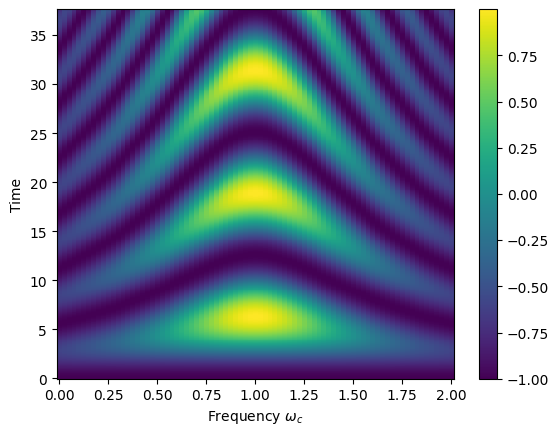

In [9]:
# Plot sigma Z expectation value as a function of time and cavity frequency for the JC model
Y, X = np.meshgrid(simulation.timeList, freqSweep.sweepList)
plt.pcolormesh(X, Y, simulation.resultsDict['zJC'])
plt.colorbar()
plt.xlabel(r"Frequency $\omega_{c}$")
plt.ylabel("Time")

The Rabi model plot shows:
- **Similar overall pattern** to JC model at these parameters
- **Slight asymmetry**: Counter-rotating terms break perfect symmetry
- **Modified oscillation frequency**: Anti-resonant terms shift dynamics
- **Bloch-Siegert shift**: Small frequency correction from $a^{\dagger}\sigma_{+}$ and $a\sigma_{-}$


Text(0, 0.5, 'Time')

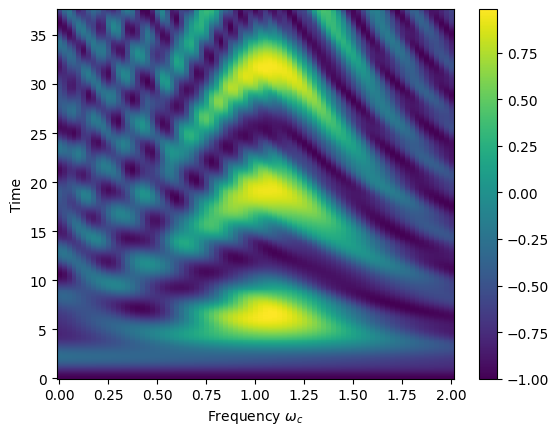

In [10]:
# Plot sigma Z expectation value as a function of time and cavity frequency for the Rabi model
Y, X = np.meshgrid(simulation.timeList, freqSweep.sweepList)
plt.pcolormesh(X, Y, simulation.resultsDict['zRabi'])
plt.colorbar()
plt.xlabel(r"Frequency $\omega_{c}$")
plt.ylabel("Time")

The fidelity plot compares the JC and Rabi states at the same time and cavity frequency.

High fidelity indicates the RWA (JC model) reproduces the full Rabi dynamics.

When the cavity frequency is comparable to the coupling ($\omega_{c} \approx g$), the counter-rotating terms no longer oscillate fast enough to average out and we see:
- Drops in fidelity (JC and Rabi model disagree)
- The chevron symmetry distorts
- Bloch–Siegert shift becomes non-negligible


When $\omega_{c}$ (and $\omega_{q}$) $ \gg g$, the fast oscillations of the counter-rotating terms suppress their net effect and the RWA holds. In this reigime, we observe:
- High fidelity persists even when not on resonance.
- JC and Rabi chevrons closely match with minimal asymmetries.
- Bloch–Siegert corrections are small and often within numerical/plot resolution.


Text(0, 0.5, 'Time')

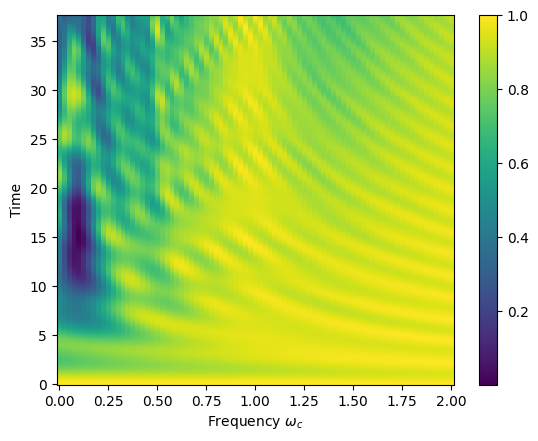

In [11]:
# Plot the fidelity between JC and Rabi model as a function of time and cavity frequency
Y, X = np.meshgrid(simulation.timeList, freqSweep.sweepList)
plt.pcolormesh(X, Y, simulation.resultsDict['fidelityJC'])
plt.colorbar()
plt.xlabel(r"Frequency $\omega_{c}$")
plt.ylabel("Time")